### Run it in case of using Colab servers

In [ ]:
import sys
!rm -rf LiFIMI_Attack
!git clone https://github.com/Vegnics/LiFIMI_Attack.git
sys.path.append("./LiFIMI_Attack")

In [1]:
import os, sys, inspect, time
"""
solve the conflict between paths, and work dir
"""
sys.path.append('../')
os.chdir('../')
print(sys.path)
print(os.getcwd())

import numpy as np
import torch 
import matplotlib.pyplot as plt
torch.multiprocessing.set_sharing_strategy('file_system')

import lfi
from lfi.utils import discrepancy, visualization
from lfi.algorithms import ABC_algorithms, SMCABC, SMC2ABC, SNLABC, SNL2ABC
from lfi.detsimul import problem_FFD,problem_FFD_image
from lfi.utils import uos, umath

#%load_ext autoreload
#%autoreload 2

['/home/amaranth2/miniconda3/envs/itcff/lib/python311.zip', '/home/amaranth2/miniconda3/envs/itcff/lib/python3.11', '/home/amaranth2/miniconda3/envs/itcff/lib/python3.11/lib-dynload', '', '/home/amaranth2/miniconda3/envs/itcff/lib/python3.11/site-packages', '../']
/home/amaranth2/ITC_FF


/home/amaranth2/Downloads/SimpleFace/face_0033.jpg
/home/amaranth2/Downloads/SimpleFace/face_0012.jpg
Wimages shape:: (400, 256, 256, 3)
Images shape:: (400, 256, 256, 3)
[True posterior] pilot run 
finished pilot run: 500
finished pilot run: 1000
finished pilot run: 1500
finished pilot run: 2000
finished pilot run: 2500
finished pilot run: 3000
finished pilot run: 3500
finished pilot run: 4000
finished pilot run: 4500
finished pilot run: 5000
finished pilot run: 5500
finished pilot run: 6000
finished pilot run: 6500
finished pilot run: 7000
finished pilot run: 7500
finished pilot run: 8000
finished pilot run: 8500
finished pilot run: 9000
finished pilot run: 9500
finished pilot run: 10000
finished pilot run: 10500
finished pilot run: 11000
finished pilot run: 11500
finished pilot run: 12000
finished pilot run: 12500
finished pilot run: 13000
finished pilot run: 13500
finished pilot run: 14000
finished pilot run: 14500
finished pilot run: 15000
finished pilot run: 15500
finished pilot 

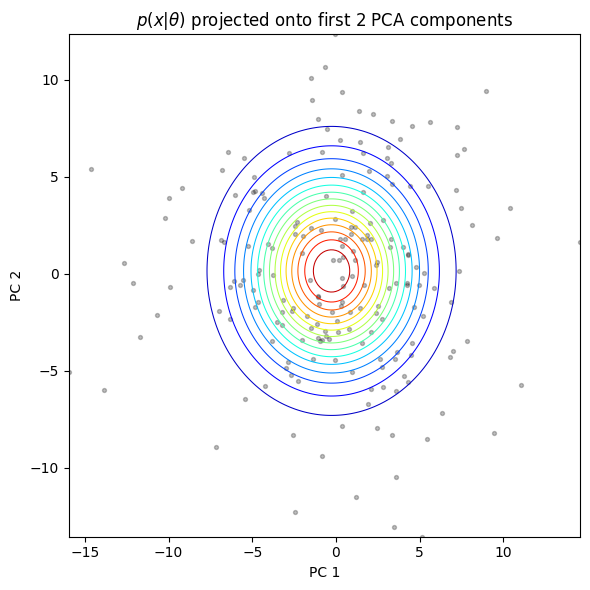

mean-parma1 =  0.12620824976410938      mean-param2 =  50.70519547228625


<Figure size 500x400 with 0 Axes>

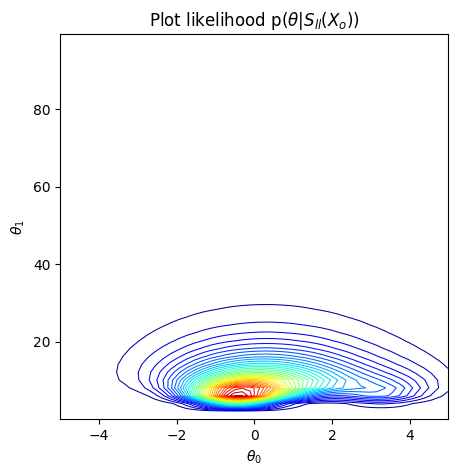

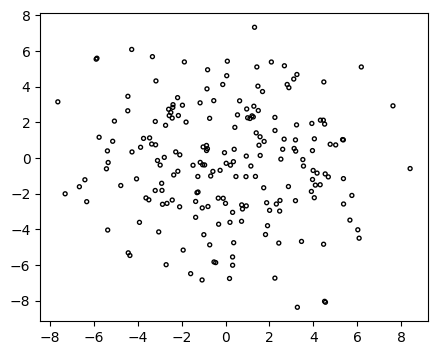

In [2]:
DIR = 'results/FFD' 
IMG_FOLDER = "/home/amaranth2/Downloads/SimpleFace"
OUT_FOLDER = "/home/quinoa/out_folder"
problem = problem_FFD_image.FFD_Image_Problem(N=500, n=200)
problem.img_folder = IMG_FOLDER
problem.out_img_folder = OUT_FOLDER
problem.true_mean = 0.0
problem.true_var = 10.0
problem.get_work_imgs()
true_theta = problem.get_true_theta()
## The generated images are stored in a folder
## data_obs contains only the deformation parameters

## The simulator returns the observed mu params and 
## the deformed images
problem.data_obs, problem.imgs_obs = problem.simulator(true_theta)
## Compute PCA over the observed data
problem.compute_pca(n_components=15)
## Pick a mu param
#problem.y_obs, problem.imgs_obs = problem.statistics(data=problem.data_obs,images=problem.imgs_obs, theta=true_theta)
problem.y_obs, _ = problem.statistics(data=problem.data_obs,images=problem.imgs_obs, theta=true_theta)

## Sample thetas from the true posterior
true_samples = problem.sample_from_true_posterior()
## Get the true theta
theta_true = problem.get_true_theta()

## Visualize the likelihood of the samples p(x|theta)
problem.visualize()
plt.figure(figsize=(5,4))
visualization.plot_likelihood(samples=true_samples,
                              log_likelihood_function=problem.log_likelihood,
                              dimensions=(0,1),
                              bounded = False)#,n_levels=10)
plt.show()
visualization.plot_samples(problem.data_obs)
#uos.save_object(DIR, 'true_samples', true_samples)

In [3]:
## Sequential Neural Likelihood
hyperparams = ABC_algorithms.Hyperparams()
hyperparams.save_dir = DIR
#hyperparams.device = 'cuda:1'
hyperparams.device = 'cpu'

hyperparams.num_sim = 400 #100#4000                       # number of sampling/simulation rounds
hyperparams.L = 2                                # number of learning rounds
#hyperparams.type = 'cnn2d'                       # the network architecture of S(x)
hyperparams.type = 'cnnimg'
hyperparams.stat = 'infomax'                     # statistics function: infomax/moment/score  
hyperparams.estimator = 'DC'                     # MI estimator; JSD (accurate) or DC (fast)
hyperparams.nde = 'MAF'                          # nde; MAF (D>1) or MDN (D=1)
from lfi.utils import discrepancy, visualization

print('\n SNL ABC')
print(f"Imgs observed: {problem.imgs_obs.shape}")
problem.n = 2
snl_abc = SNL2ABC.SNL2_ABC_Image(problem, discrepancy=discrepancy.eculidean_dist, hyperparams=hyperparams)
snl_abc.run()

JSD_array = []
for l in range(len(snl_abc.nde_array)):
    print('l=', l)
    snl_abc.nde_net = snl_abc.nde_array[l]
    visualization.plot_likelihood(samples=true_samples, log_likelihood_function=snl_abc.log_likelihood, dimensions=(0,1),bounded=False)
    JSD = discrepancy.JSD(problem.log_likelihood, snl_abc.log_likelihood, true_samples, true_samples, N_grid=30)
    JSD_array.append(JSD)
    print('JSD snl = ', JSD)
uos.save_object(DIR, 'JSD_SNL', JSD_array)


 SNL ABC
Imgs observed: (400, 256, 256, 3)
Images shape:: (400, 256, 256, 3)
iteration  0
# of cpus =  4
[ABC] sub-process start!
Wimages shape:: (4, 256, 256, 3)
Images shape:: (4, 256, 256, 3)
Wimages shape:: (4, 256, 256, 3)
Images shape:: (4, 256, 256, 3)
Wimages shape:: (4, 256, 256, 3)
Images shape:: (4, 256, 256, 3)
[ABC] sub-process start!
Wimages shape:: (4, 256, 256, 3)
Images shape:: (4, 256, 256, 3)
Wimages shape:: (4, 256, 256, 3)
Images shape:: (4, 256, 256, 3)
Wimages shape:: (4, 256, 256, 3)
Images shape:: (4, 256, 256, 3)
Wimages shape:: (4, 256, 256, 3)
Images shape:: (4, 256, 256, 3)
Wimages shape:: (4, 256, 256, 3)
Images shape:: (4, 256, 256, 3)
Wimages shape:: (4, 256, 256, 3)
Images shape:: (4, 256, 256, 3)
Wimages shape:: (4, 256, 256, 3)
Images shape:: (4, 256, 256, 3)
Wimages shape:: (4, 256, 256, 3)
Images shape:: (4, 256, 256, 3)
Wimages shape:: (4, 256, 256, 3)
Images shape:: (4, 256, 256, 3)
[ABC] sub-process start!
Wimages shape:: (4, 256, 256, 3)
Images

KeyboardInterrupt: 